# Model Explainability
 
**Objectives:**
- Understand which features drive predictions globally (SHAP summary)
- Explain individual predictions (SHAP waterfall + LIME)
- Validate model behaviour makes domain sense

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from pathlib import Path

import shap
import lime
import lime.lime_tabular

warnings.filterwarnings('ignore')

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR    = Path('./models')
RANDOM_STATE  = 42

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120})

X_train = pd.read_csv(PROCESSED_DIR / 'X_train_selected.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test_selected.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()

model = joblib.load(MODELS_DIR / 'best_model.pkl')
print(f'Loaded model: {type(model).__name__}')
print(f'X_test shape: {X_test.shape}')

Loaded model: XGBClassifier
X_test shape: (6336, 20)


## 1. SHAP - Global Explanations
SHAP (SHapley Additive exPlanations) computes each feature's marginal contribution 
to each prediction using game-theory Shapley values. 

I used TreeExplainer - optimised for tree-based models (XGBoost/LightGBM).

In [6]:
from sklearn.linear_model import LogisticRegression

# Choose correct explainer based on model type
if isinstance(model, LogisticRegression):
    explainer   = shap.LinearExplainer(model, X_train, feature_perturbation='interventional')
    shap_values = explainer.shap_values(X_test)
    # LinearExplainer returns 1D for binary - wrap if needed
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
else:
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    # XGBoost/LGBM TreeExplainer returns 2D for binary - take class 1
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

print(f'SHAP values shape: {shap_values.shape}')
print('SHAP computation complete.')

SHAP values shape: (6336, 20)
SHAP computation complete.


### 1a. Summary Plot (Beeswarm)
Each dot = one sample. X-axis = SHAP value (impact on prediction).  
Color = feature value (red = high, blue = low).  

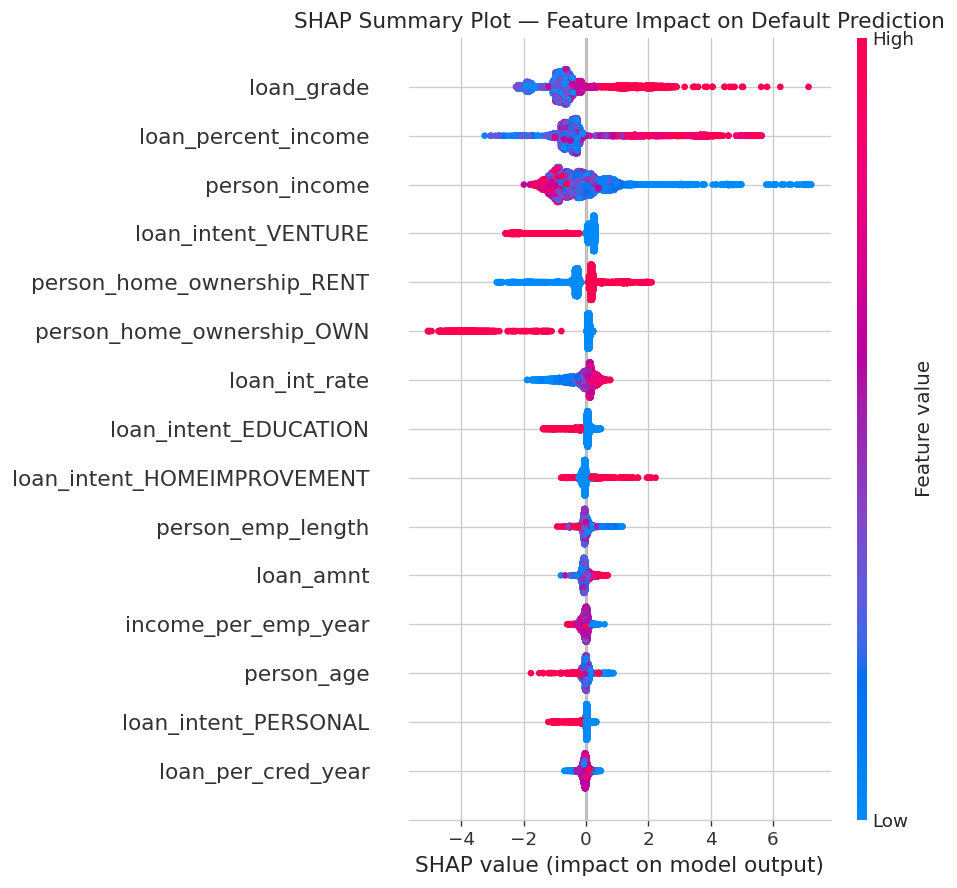

In [7]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type='dot',
                  show=False, max_display=15)
plt.title('SHAP Summary Plot — Feature Impact on Default Prediction', fontsize=13)
plt.tight_layout()
plt.show()


**Expected findings for credit risk:**
- `loan_int_rate`: high rate (red) -> high positive SHAP -> increases default risk
- `loan_grade`: high grade number (red = riskier grade) -> increases default risk 
- `loan_percent_income`: high fraction (red) -> increases default risk 

### 1b. Bar Plot - Mean Absolute SHAP (Global Importance)

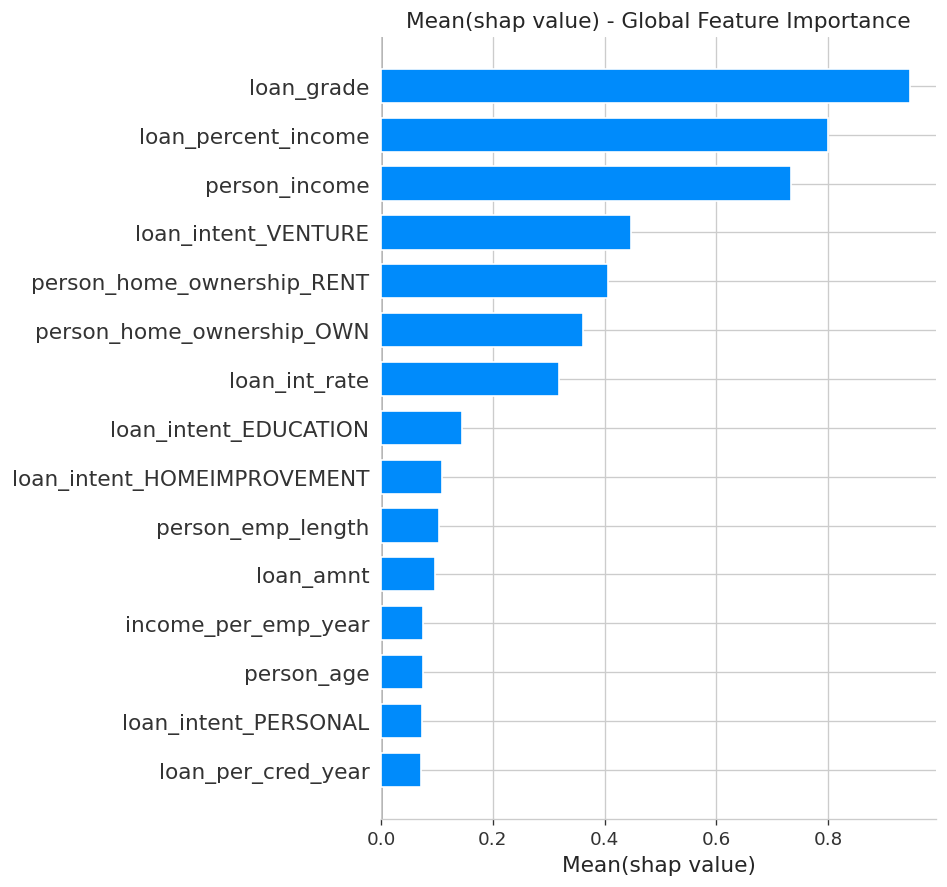

In [21]:
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar',
                  show=False, max_display=15)
plt.title('Mean(shap value) - Global Feature Importance', fontsize=13)
plt.xlabel('Mean(shap value)')
plt.tight_layout()
plt.show()

### 1c. SHAP Dependence Plots
Dependence plots show how a single feature's SHAP value varies with its actual value,
coloured by the most interacting feature. Good for spotting non-linear effects.

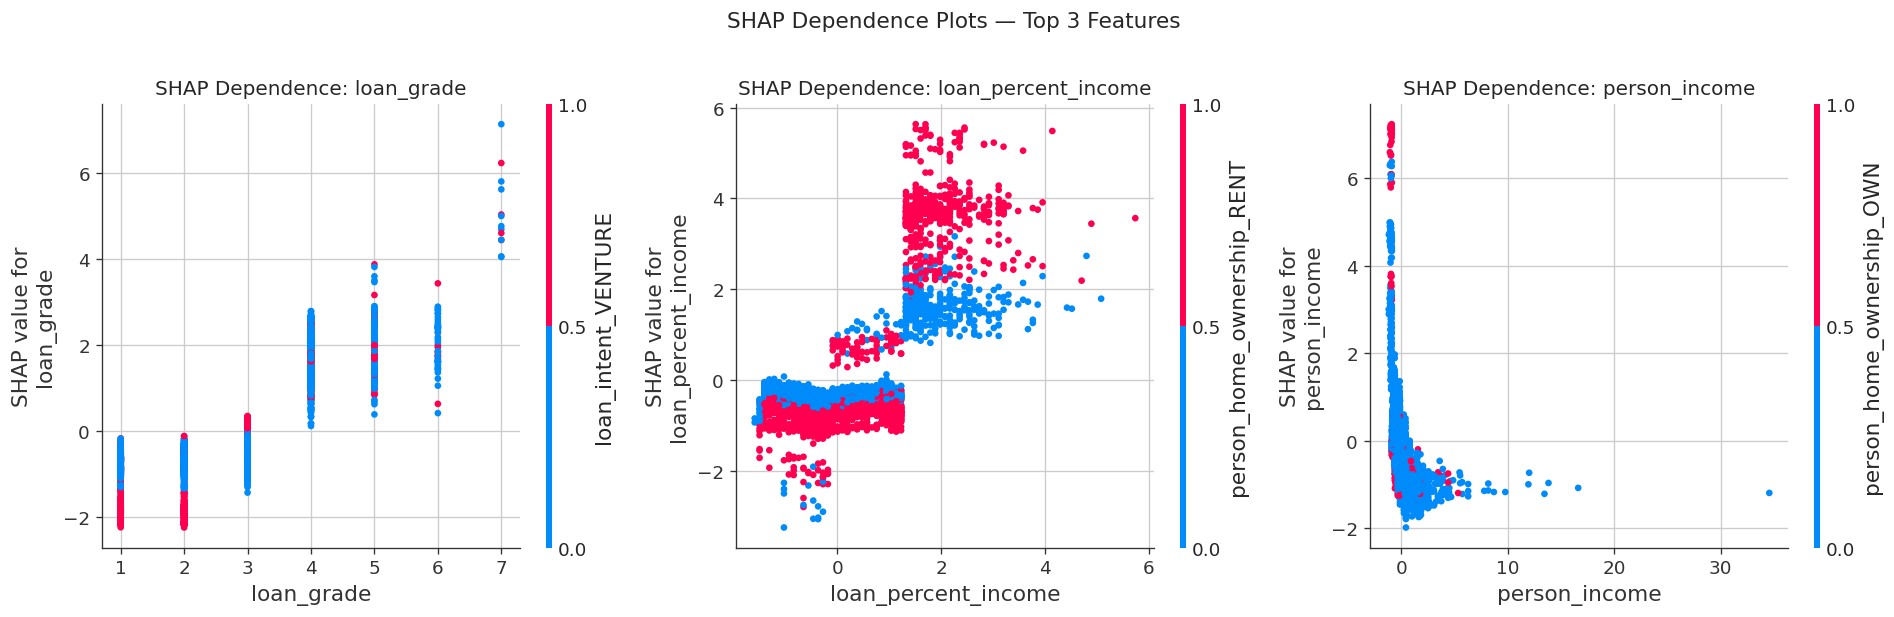

In [9]:
# Get top 3 features by mean absolute SHAP
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top3_idx      = np.argsort(mean_abs_shap)[::-1][:3]
top3_features = X_test.columns[top3_idx].tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, top3_features):
    shap.dependence_plot(feat, shap_values, X_test,
                         ax=ax, show=False)
    ax.set_title(f'SHAP Dependence: {feat}')

plt.suptitle('SHAP Dependence Plots — Top 3 Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 2. SHAP - Local Explanations (on Individual Predictions)
While global plots explain overall model behaviour, local explanations show 
*why* the model made a specific prediction for a single applicant.

We examine two cases:
- A **high-risk** applicant correctly predicted as default
- A **low-risk** applicant correctly predicted as no default

In [10]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred  = model.predict(X_test)

# Correct high-risk prediction (true default, predicted default)
true_defaults = np.where((y_test.values == 1) & (y_pred == 1))[0]
high_risk_idx = true_defaults[np.argmax(y_proba[true_defaults])]

# Correct low-risk prediction (true no-default, predicted no-default)
true_safe = np.where((y_test.values == 0) & (y_pred == 0))[0]
low_risk_idx = true_safe[np.argmin(y_proba[true_safe])]

print(f'High-risk sample index: {high_risk_idx} | P(default) = {y_proba[high_risk_idx]:.4f}')
print(f'Low-risk sample index : {low_risk_idx}  | P(default) = {y_proba[low_risk_idx]:.4f}')

High-risk sample index: 1554 | P(default) = 1.0000
Low-risk sample index : 2230  | P(default) = 0.0001


### 2a. Waterfall Plot - High-Risk Applicant
The waterfall plot shows feature contributions stacked from the base value 
(average model output) to the final prediction.

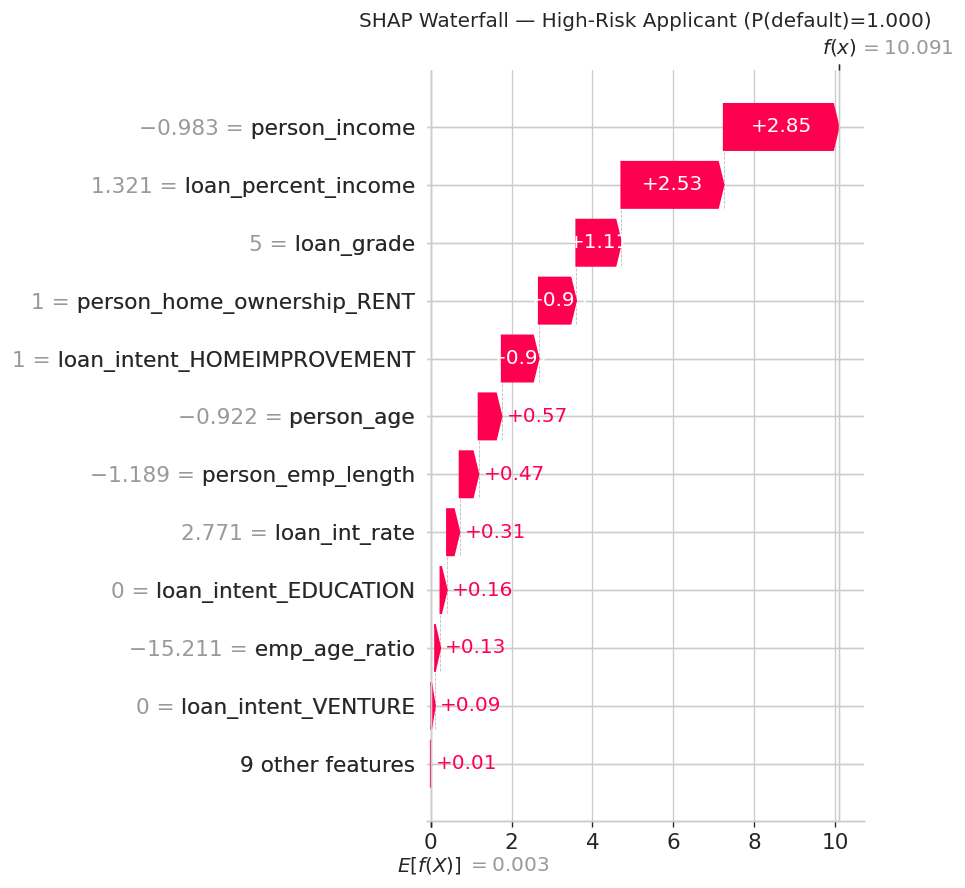

In [11]:
shap_exp = shap.Explanation(
    values          = shap_values[high_risk_idx],
    base_values     = explainer.expected_value if not isinstance(explainer.expected_value, list)
                      else explainer.expected_value[1],
    data            = X_test.iloc[high_risk_idx].values,
    feature_names   = X_test.columns.tolist()
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp, max_display=12, show=False)
plt.title(f'SHAP Waterfall — High-Risk Applicant (P(default)={y_proba[high_risk_idx]:.3f})',
          fontsize=12)
plt.tight_layout()
plt.show()

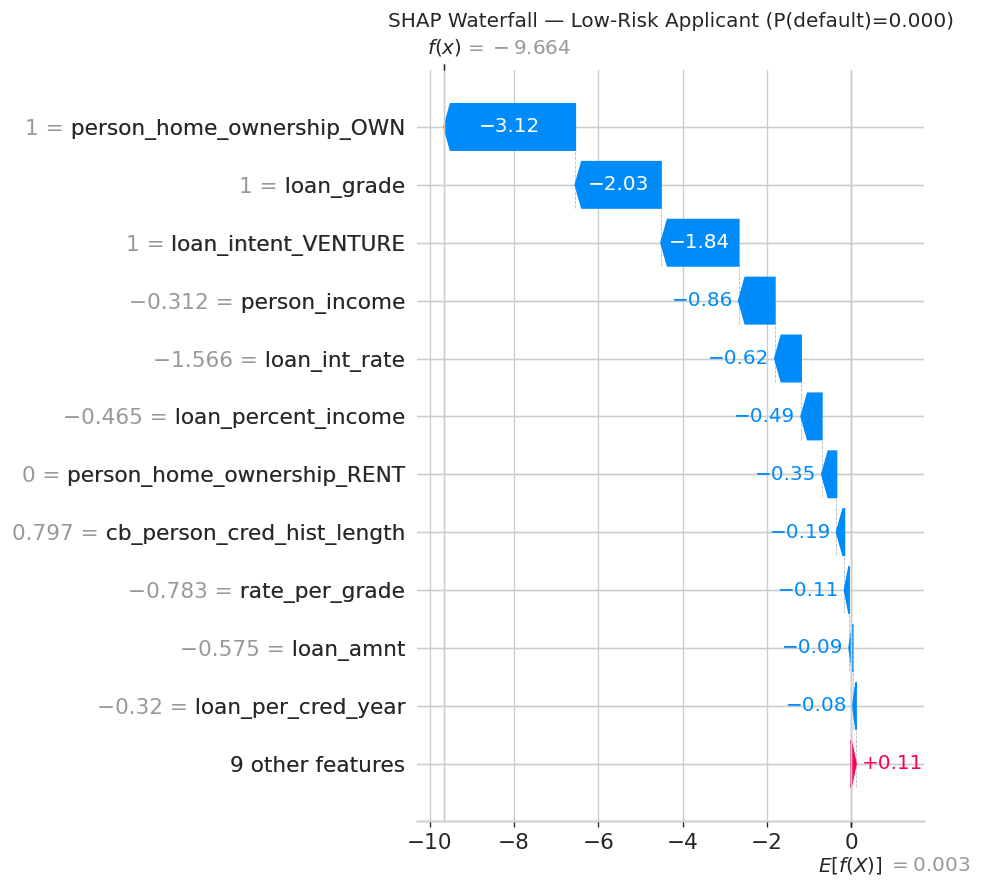

In [12]:
shap_exp_safe = shap.Explanation(
    values        = shap_values[low_risk_idx],
    base_values   = explainer.expected_value if not isinstance(explainer.expected_value, list)
                    else explainer.expected_value[1],
    data          = X_test.iloc[low_risk_idx].values,
    feature_names = X_test.columns.tolist()
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp_safe, max_display=12, show=False)
plt.title(f'SHAP Waterfall — Low-Risk Applicant (P(default)={y_proba[low_risk_idx]:.3f})',
          fontsize=12)
plt.tight_layout()
plt.show()

## 3. LIME - Local Explanations
LIME (Local Interpretable Model-agnostic Explanations) fits a simple linear model 
around a single prediction to approximate local behaviour.

Unlike SHAP, LIME is model-agnostic - it works by perturbing the input and 
observing how predictions change. Useful as a cross-check against SHAP.

In [13]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data   = X_train.values,
    feature_names   = X_train.columns.tolist(),
    class_names     = ['No Default', 'Default'],
    mode            = 'classification',
    random_state    = RANDOM_STATE
)

print('LIME explainer ready.')

LIME explainer ready.


### 3a. LIME - High-Risk Applicant

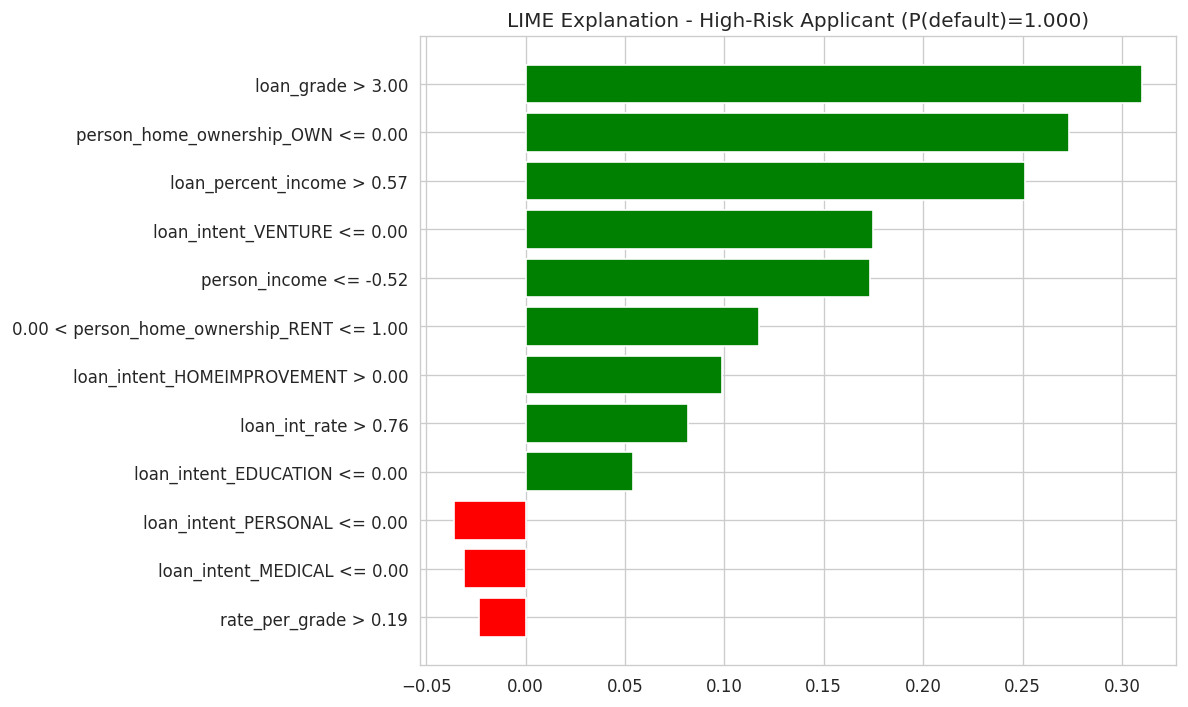

In [22]:
lime_exp_high = lime_explainer.explain_instance(
    data_row        = X_test.iloc[high_risk_idx].values,
    predict_fn      = model.predict_proba,
    num_features    = 12,
    num_samples     = 1000
)

fig = lime_exp_high.as_pyplot_figure()
fig.set_size_inches(10, 6)
plt.title(f'LIME Explanation - High-Risk Applicant (P(default)={y_proba[high_risk_idx]:.3f})',
          fontsize=12)
plt.tight_layout()
plt.show()

### 3b. LIME - Low-Risk Applicant

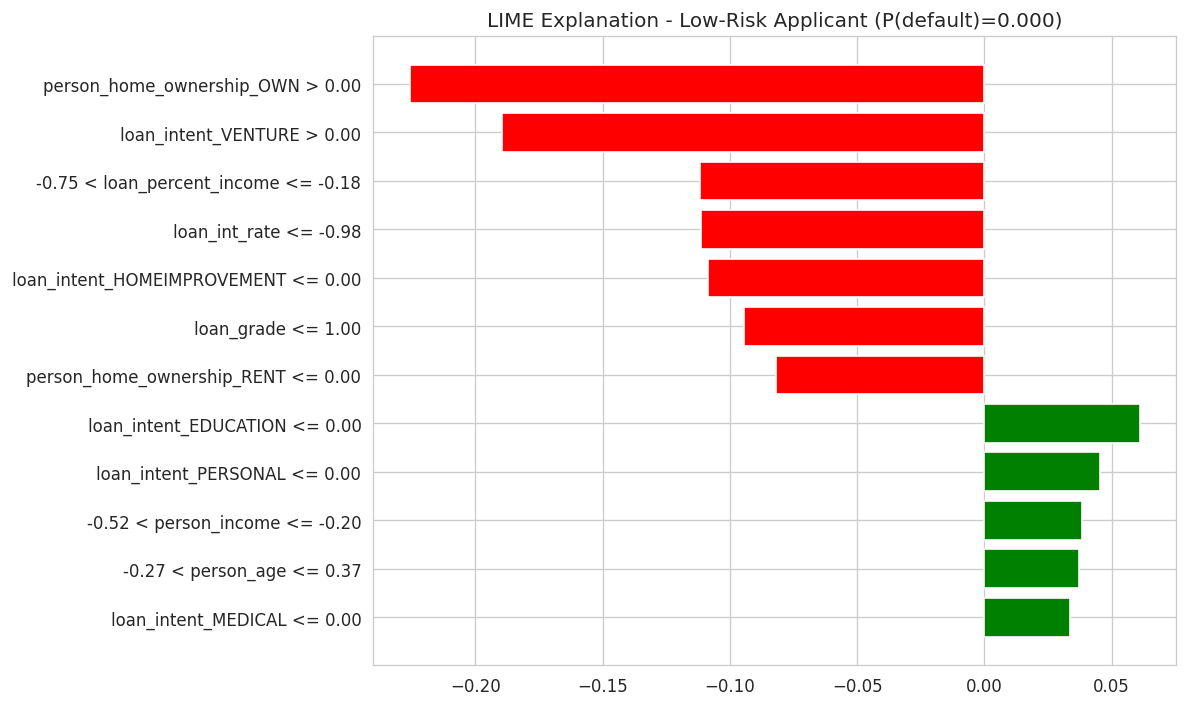

In [23]:
lime_exp_low = lime_explainer.explain_instance(
    data_row        = X_test.iloc[low_risk_idx].values,
    predict_fn      = model.predict_proba,
    num_features    = 12,
    num_samples     = 1000
)

fig = lime_exp_low.as_pyplot_figure()
fig.set_size_inches(10, 6)
plt.title(f'LIME Explanation - Low-Risk Applicant (P(default)={y_proba[low_risk_idx]:.3f})',
          fontsize=12)
plt.tight_layout()
plt.show()

## 4. SHAP vs LIME - Consistency Check
A trustworthy model should show agreement between SHAP and LIME on the same sample.
We compare the top 5 features from each method for both cases.

In [25]:
def get_lime_top_features(lime_exp, n=5):
    """Extract top n feature names from a LIME explanation by absolute weight."""
    feats = lime_exp.as_list()
    return pd.DataFrame(feats, columns=['Feature', 'LIME Weight']).head(n)

def get_shap_top_features(shap_vals, feature_names, sample_idx, n=5):
    """Extract top n features from SHAP values for a given sample by absolute value."""
    s = pd.Series(shap_vals[sample_idx], index=feature_names)
    return s.abs().sort_values(ascending=False).head(n).rename('SHAP').reset_index()

print('=== High-Risk Applicant ===')
print('\nTop SHAP features:')
print(get_shap_top_features(shap_values, X_test.columns.tolist(), high_risk_idx).to_string(index=False))
print('\nTop LIME features:')
print(get_lime_top_features(lime_exp_high).to_string(index=False))

print('\n=== Low-Risk Applicant ===')
print('\nTop SHAP features:')
print(get_shap_top_features(shap_values, X_test.columns.tolist(), low_risk_idx).to_string(index=False))
print('\nTop LIME features:')
print(get_lime_top_features(lime_exp_low).to_string(index=False))

=== High-Risk Applicant ===

Top SHAP features:
                      index     SHAP
              person_income 2.845327
        loan_percent_income 2.533166
                 loan_grade 1.113423
 person_home_ownership_RENT 0.926652
loan_intent_HOMEIMPROVEMENT 0.916026

Top LIME features:
                          Feature  LIME Weight
                loan_grade > 3.00     0.309928
person_home_ownership_OWN <= 0.00     0.273193
       loan_percent_income > 0.57     0.251453
      loan_intent_VENTURE <= 0.00     0.174681
           person_income <= -0.52     0.173024

=== Low-Risk Applicant ===

Top SHAP features:
                    index     SHAP
person_home_ownership_OWN 3.116537
               loan_grade 2.034714
      loan_intent_VENTURE 1.843420
            person_income 0.857510
            loan_int_rate 0.624737

Top LIME features:
                             Feature  LIME Weight
    person_home_ownership_OWN > 0.00    -0.225838
          loan_intent_VENTURE > 0.00    -0.189438


## 5. Explainability Summary

| Aspect | SHAP | LIME |
|---|---|---|
| **Scope** | Global + local | Local only |
| **Speed** | Fast (TreeExplainer) | Slower (perturbation-based) |
| **Consistency** | Guaranteed (Shapley axioms) | Approximation — can vary by run |
| **Best for** | Understanding model globally; feature importance | Cross-checking individual predictions |

**Domain validation checklist:**
- [ ] `loan_grade` is a top predictor with correct direction (higher grade number = more risk)
- [ ] `loan_int_rate` positively associated with default
- [ ] `loan_percent_income` positively associated with default
- [ ] `cb_person_default_on_file` increases risk when Y (encoded as 1)